# Exponential families and conjugacy

The single structure that unifies most of the distributions in this library - the exponential family $p(x\mid\eta)=h(x)\exp(\eta\cdot T(x)-A(\eta))$ - and the three things it explains at once: why a handful of sufficient statistics $T(x)$ summarize the data (mixle's accumulators), why maximum likelihood is moment matching, and why conjugate priors turn Bayesian updating into simple addition in statistic-space.


## Definition and the canonical form

Definition (exponential family). A family $\{p(\cdot\mid\theta)\}$ is an exponential family if its
densities can be written
$$p(x\mid\theta) = h(x)\,\exp\!\big(\eta(\theta)^\top T(x) - A(\theta)\big),$$
where $T(x)$ is the vector of sufficient statistics, $\eta(\theta)$ the natural (canonical) parameter,
$h(x)\ge 0$ the base measure, and $A$ the log-partition function fixed by normalization. In the
canonical parameterization $\eta$ is the parameter and
$$A(\eta) = \log\!\int h(x)\,e^{\eta^\top T(x)}\,dx.$$

Most familiar distributions are of this form: Bernoulli, binomial, Poisson, geometric, exponential,
gamma, Gaussian, categorical, multinomial. The uniform, the Cauchy, and finite mixtures are not, and the
final section explains why that matters.

Example (Poisson). $p(x\mid\lambda)=e^{-\lambda}\lambda^x/x!$ rewrites as
$\tfrac{1}{x!}\exp(x\log\lambda - \lambda)$, so $T(x)=x$, $\eta=\log\lambda$, $A(\eta)=e^\eta=\lambda$,
and $h(x)=1/x!$.

## The log-partition function generates the moments

Theorem (cumulant property). On the canonical parameterization the gradient and Hessian of the
log-partition function are the mean and covariance of the sufficient statistic:
$$\nabla_\eta A(\eta) = \mathbb E_\eta[T(X)], \qquad \nabla^2_\eta A(\eta) = \mathrm{Cov}_\eta(T(X)).$$
In particular $A$ is convex, and strictly convex when $T$ has no affine dependence.

Proof. Differentiate $A(\eta)=\log\int h\,e^{\eta^\top T}dx$. The gradient is
$$\nabla_\eta A = \frac{\int T\,h\,e^{\eta^\top T}dx}{\int h\,e^{\eta^\top T}dx}
   = \int T(x)\,p(x\mid\eta)\,dx = \mathbb E_\eta[T].$$
Differentiating once more,
$$\nabla^2_\eta A = \int T T^\top p\,dx - \Big(\int T p\,dx\Big)\Big(\int T p\,dx\Big)^\top
   = \mathbb E_\eta[TT^\top] - \mathbb E_\eta[T]\mathbb E_\eta[T]^\top = \mathrm{Cov}_\eta(T).$$
A covariance matrix is positive semidefinite, so $A$ is convex. $\quad\blacksquare$

Theorem (maximum likelihood is moment matching). Given iid data, the canonical MLE $\hat\eta$ solves
$$\nabla_\eta A(\hat\eta) = \tfrac1n\sum_i T(x_i), \qquad\text{that is}\qquad
  \mathbb E_{\hat\eta}[T] = \overline{T},$$
the fitted mean of the sufficient statistic equals its sample mean.

Proof. The log-likelihood is $\ell_n(\eta)=\sum_i\big(\eta^\top T(x_i) - A(\eta)\big) + \text{const}$.
Setting $\nabla_\eta \ell_n = \sum_i T(x_i) - n\nabla_\eta A(\eta) = 0$ and dividing by $n$ gives the
claim. Convexity of $A$ makes $-\ell_n$ convex, so this stationary point is the unique global maximum
when it exists. $\quad\blacksquare$

This is exactly what a mixle accumulator does: it sums $T(x_i)$, and fitting solves the moment
equation. It also explains the consistency of the picture in the MLE notebook, where the Gaussian
estimate depended only on $\sum x_i$ and $\sum x_i^2$.

## Maximum entropy and conjugacy

Theorem (maximum entropy). Among all densities with a prescribed mean $\mathbb E[T(X)]=\mu$ of the
statistic $T$, the one of maximum (differential) entropy is the exponential family member with that mean.

Proof sketch. Maximize $-\int p\log p\,dx$ subject to $\int p\,dx=1$ and $\int T p\,dx=\mu$ with
Lagrange multipliers $A$ and $\eta$. The stationarity condition $-\log p - 1 - A + \eta^\top T = 0$ gives
$p\propto \exp(\eta^\top T)$, the exponential-family form; the multipliers are chosen to meet the
constraints. $\quad\blacksquare$

This is why exponential families are the natural "least-committal" models given moment information.

Definition (conjugate prior). A prior is conjugate to a likelihood if the posterior belongs to the same
family as the prior. For a canonical exponential-family likelihood the conjugate prior is
$$\pi(\eta\mid\tau,\nu) \propto \exp\!\big(\tau^\top \eta - \nu\,A(\eta)\big),$$
itself an exponential family in $\eta$ with statistics $(\eta, -A(\eta))$ and hyperparameters
$(\tau,\nu)$.

Theorem (closed-form update). With this prior and iid data $x_1,\dots,x_n$, the posterior is the same
family with updated hyperparameters
$$\tau \mapsto \tau + \sum_i T(x_i), \qquad \nu \mapsto \nu + n.$$

Proof. The posterior is proportional to prior times likelihood,
$\exp\!\big(\tau^\top\eta - \nu A(\eta)\big)\,\exp\!\big(\eta^\top\sum_i T(x_i) - n A(\eta)\big)
= \exp\!\big((\tau+\sum_i T(x_i))^\top\eta - (\nu+n)A(\eta)\big)$, which is the prior form with the stated
hyperparameters. $\quad\blacksquare$

So Bayesian updating in an exponential family is addition in the space of sufficient statistics: the
hyperparameters act as pseudo-counts and pseudo-data. Beta-Bernoulli, gamma-Poisson, and
NormalGamma-Gaussian are all instances; mixle's `prior=` and conjugate `fit` implement exactly
this addition.

## Counterexample: distributions that are not exponential families

The structure above is special, not universal. Two facts mark the boundary.

The uniform family $\mathrm{Uniform}(0,\theta)$ is not an exponential family: its support depends on
$\theta$, so it cannot be written with a $\theta$-free base measure $h(x)$. The Cauchy family is not an
exponential family either, despite having fixed support, because its log-density is not affine in any
finite statistic.

Theorem (Pitman-Koopman-Darmois). Among families with common support and suitable smoothness, a
sufficient statistic whose dimension does not grow with the sample size exists only for exponential
families.

The consequence is practical. For an exponential family you can summarize any amount of data in a
fixed-size accumulator and fit in one streaming pass. For a non-exponential family such as the Cauchy you
cannot: there is no finite lossless summary, the order statistics themselves are minimal sufficient, and
estimation needs the whole sample. This is the dividing line between models mixle fits by merging
accumulators and models that require iterative full-data optimization.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import Bernoulli, Beta, Poisson, Gamma, Normal
rng = np.random.RandomState(0)

## 1. One form, many distributions

A distribution is in the exponential family if its density can be written

$$p(x\mid\eta)=h(x)\,\exp\big(\eta\cdot T(x)-A(\eta)\big),$$

with natural parameter $\eta$, sufficient statistic $T(x)$, log-partition $A(\eta)$, and base measure $h(x)$. Most everyday distributions fit this mold - they differ only in $T$ and $A$:

| family | sufficient statistic $T(x)$ | natural parameter $\eta$ |
|---|---|---|
| Bernoulli$(p)$ | $x$ | $\log\frac{p}{1-p}$ (the logit) |
| Poisson$(\lambda)$ | $x$ | $\log\lambda$ |
| Gaussian$(\mu,\sigma^2)$ | $(x,\,x^2)$ | $(\mu/\sigma^2,\,-1/2\sigma^2)$ |
| Gamma$(\alpha,\beta)$ | $(\log x,\,x)$ | $(\alpha-1,\,-\beta)$ |

Two facts fall straight out of the form. (i) Sufficiency: the likelihood touches the data only through $\sum_i T(x_i)$ - those sums are all you need (which is exactly what an accumulator stores). (ii) MLE = moment matching: $\nabla A(\eta)=\mathbb{E}[T(x)]$, so the MLE sets the model's expected statistic equal to the empirical one.


In [2]:
# MLE = moment matching, shown on the Gaussian (T = (x, x^2))
x = rng.normal(3.0, 2.0, 2000)
T1, T2 = x.mean(), (x ** 2).mean()                 # empirical E[x], E[x^2]
mu_hat, var_hat = T1, T2 - T1 ** 2                  # solving E_model[T] = empirical T
print('matched moments -> mu=%.3f  var=%.3f  (the Gaussian MLE)' % (mu_hat, var_hat))
print('the fit used the data ONLY through the sufficient statistics (sum x, sum x^2)')

matched moments -> mu=2.968  var=3.827  (the Gaussian MLE)
the fit used the data ONLY through the sufficient statistics (sum x, sum x^2)


## 2. Conjugacy is addition in statistic-space

A prior is conjugate to an exponential-family likelihood when the posterior stays in the same family - and then Bayesian updating is just adding the data's sufficient statistics to the prior's pseudo-counts. Three canonical pairs, each a one-liner in `mixle.ppl` (a distribution in a parameter slot is a prior; conjugacy makes the fit a closed-form posterior, no sampling):

- Beta-Bernoulli: prior $\mathrm{Beta}(a,b)$, data with $s$ successes in $n$ → posterior $\mathrm{Beta}(a+s,\ b+n-s)$.
- Gamma-Poisson: prior $\mathrm{Gamma}(\alpha,\beta)$, counts summing to $S$ over $n$ → posterior $\mathrm{Gamma}(\alpha+S,\ \beta+n)$.
- Normal-Normal (known variance): the posterior mean is a precision-weighted average of prior mean and sample mean.

We compute each update by hand and confirm mixle's conjugate fit agrees.


In [3]:
# Beta-Bernoulli
flips = (rng.random(200) < 0.3).astype(float); s, n = flips.sum(), len(flips)
a, b = 2.0, 2.0
post_mean_hand = (a + s) / (a + b + n)
mixle_p = Bernoulli(Beta(a, b, name='p')).fit(list(flips)).dist.p
print('Beta-Bernoulli  posterior mean: hand=%.3f  mixle=%.3f  (true 0.30)' % (post_mean_hand, mixle_p))

# Gamma-Poisson
counts = rng.poisson(4.0, 300).astype(float); S = counts.sum()
alpha, beta = 3.0, 1.0
post_rate_hand = (alpha + S) / (beta + len(counts))
mixle_lam = Poisson(Gamma(alpha, beta, name='rate')).fit(list(counts)).dist.lam
print('Gamma-Poisson   posterior mean: hand=%.3f  mixle=%.3f  (true 4.00)' % (post_rate_hand, mixle_lam))

# Normal-Normal (known sd=2): precision-weighted average
ydata = rng.normal(5.0, 2.0, 100); m0, s0, sd = 0.0, 10.0, 2.0
prec0, precd = 1 / s0 ** 2, len(ydata) / sd ** 2
post_mean = (prec0 * m0 + precd * ydata.mean()) / (prec0 + precd)
mixle_mu = Normal(Normal(m0, s0, name='mu'), sd).fit(list(ydata)).summary()['mu']['mean']
print('Normal-Normal   posterior mean: hand=%.3f  mixle=%.3f  (data mean %.3f)' % (post_mean, mixle_mu, ydata.mean()))

Beta-Bernoulli  posterior mean: hand=0.284  mixle=0.284  (true 0.30)
Gamma-Poisson   posterior mean: hand=3.950  mixle=3.950  (true 4.00)
Normal-Normal   posterior mean: hand=4.933  mixle=4.933  (data mean 4.935)


The hand updates and the library agree to numerical precision - because all three are the same operation: add the data's sufficient statistics to the prior's. We can watch the Beta-Bernoulli posterior sharpen as data arrives, the prior's pseudo-counts gradually overwhelmed.


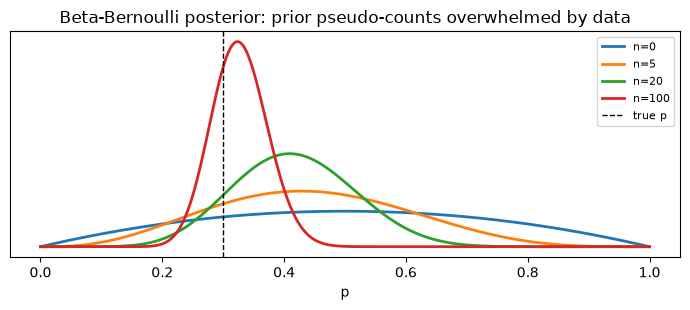

In [4]:
from scipy import stats
grid = np.linspace(0, 1, 300)
fig, ax = plt.subplots(figsize=(7, 3.2))
for n_obs in [0, 5, 20, 100]:
    s_obs = (np.random.RandomState(1).random(n_obs) < 0.3).sum() if n_obs else 0
    ax.plot(grid, stats.beta.pdf(grid, a + s_obs, b + n_obs - s_obs), lw=2, label='n=%d' % n_obs)
ax.axvline(0.3, color='k', ls='--', lw=1, label='true p')
ax.set_xlabel('p'); ax.set_yticks([]); ax.legend(fontsize=8)
ax.set_title('Beta-Bernoulli posterior: prior pseudo-counts overwhelmed by data')
plt.tight_layout(); plt.show()

## 3. The mean map $\nabla A(\eta)=\mathbb E[T]$, verified

The log-partition $A(\eta)$ is the moment generating function of the family: its gradient is the expected sufficient statistic and its Hessian is the covariance of $T$. This is what makes MLE = moment matching. We verify it for the Bernoulli, where $A(\eta)=\log(1+e^\eta)$, so $A'(\eta)=\sigma(\eta)=p=\mathbb E[x]$ and $A''(\eta)=p(1-p)=\mathrm{Var}(x)$ - checking the analytic derivatives against finite differences.


In [5]:
sigmoid = lambda e: 1.0 / (1.0 + np.exp(-e))
A = lambda e: np.log1p(np.exp(e))                 # Bernoulli log-partition
eta = 0.8
fd1 = (A(eta + 1e-5) - A(eta - 1e-5)) / 2e-5      # finite-difference A'
fd2 = (A(eta + 1e-4) - 2 * A(eta) + A(eta - 1e-4)) / 1e-8
p = sigmoid(eta)
print("A'(eta)  = %.6f   E[T]=p           = %.6f" % (fd1, p))
print("A''(eta) = %.6f   Var(T)=p(1-p)    = %.6f" % (fd2, p * (1 - p)))
print('=> the gradient of the log-partition is the mean; the Hessian is the variance.')

A'(eta)  = 0.689974   E[T]=p           = 0.689974
A''(eta) = 0.213910   Var(T)=p(1-p)    = 0.213910
=> the gradient of the log-partition is the mean; the Hessian is the variance.


## Illustration: moments from the log-partition, and conjugate updating

We check the two central claims numerically for the Poisson, whose canonical log-partition is
$A(\eta)=e^\eta=\lambda$, so $A'(\eta)=A''(\eta)=\lambda$: the mean equals the variance. Then we confirm
that the gamma-Poisson conjugate update is just addition of sufficient statistics.

In [6]:
from scipy import stats as _st
rng = np.random.RandomState(0)
lam = 4.0; eta = np.log(lam)
x = rng.poisson(lam, 200000)
print('A\'(eta)=e^eta = %.3f   sample mean E[T]    = %.3f' % (np.exp(eta), x.mean()))
print('A\'\'(eta)=e^eta = %.3f   sample variance Var[T]= %.3f  (Poisson: mean = variance)' % (np.exp(eta), x.var()))
# gamma(a,b) prior is conjugate to Poisson; posterior = gamma(a + sum x, b + n)
a0, b0 = 2.0, 1.0; data = rng.poisson(lam, 50)
a_post, b_post = a0 + data.sum(), b0 + len(data)
print('posterior gamma(a=%.0f, b=%.0f); posterior mean of lambda = %.3f (true %.1f)' %
      (a_post, b_post, a_post / b_post, lam))
print('the update added the sufficient statistic sum(x)=%d and the count n=%d to the hyperparameters.' %
      (data.sum(), len(data)))

A'(eta)=e^eta = 4.000   sample mean E[T]    = 4.002
A''(eta)=e^eta = 4.000   sample variance Var[T]= 3.998  (Poisson: mean = variance)
posterior gamma(a=187, b=51); posterior mean of lambda = 3.667 (true 4.0)
the update added the sufficient statistic sum(x)=185 and the count n=50 to the hyperparameters.


## References

- Wainwright, M. J. & Jordan, M. I. (2008). Graphical Models, Exponential Families, and Variational Inference (https://doi.org/10.1561/2200000001). Found. Trends ML 1(1-2). - the modern, unifying treatment.
- Brown, L. D. (1986). Fundamentals of Statistical Exponential Families. IMS Lecture Notes.
- Diaconis, P. & Ylvisaker, D. (1979). Conjugate priors for exponential families (https://doi.org/10.1214/aos/1176344611). Ann. Statist. 7(2), 269-281.
- Nielsen, F. & Garcia, V. (2009). Statistical exponential families: a digest with flash cards (https://arxiv.org/abs/0911.4863). arXiv:0911.4863.
- Gelman, A. et al. (2013). Bayesian Data Analysis (http://www.stat.columbia.edu/~gelman/book/), 3rd ed. CRC Press. - conjugacy in the Bayesian workflow.


## Exercises and extensions

1. Derive and verify a full exponential-family card. Pick a family not tabulated above (e.g. the Beta, the Gamma, or the von Mises). Derive its $(h(x), T(x), \eta(\theta), A(\eta))$, the mean/variance maps $\nabla A$ and $\nabla^2 A$, and the conjugate prior via Diaconis-Ylvisaker. Verify each numerically against mixle's fitted distribution (sufficient statistics, MLE = moment matching, posterior update).
2. Natural vs mean parameters and Fisher information. For the Gaussian, compute the Fisher information in both the natural parameterization $\eta$ and the usual $(\mu,\sigma^2)$, and show how they transform (the metric tensor / Jacobian). Plot the information geometry intuition: why MLE-in-$\eta$ and MLE-in-$\theta$ give the same fit but different-looking optimization landscapes.
3. Conjugacy as sequential/online Bayes. Implement streaming Beta-Bernoulli and Gamma-Poisson updates, processing data one shard at a time and merging pseudo-counts. Show order-invariance and exact agreement with a batch fit, and plot posterior contraction vs $n$. Relate to the distributed-fitting property of the exponential family.
4. When conjugacy breaks. Put a non-conjugate prior on an exponential-family parameter (e.g. a Gaussian prior on a Poisson log-rate). Show the posterior is no longer closed-form, fit it with `how='mcmc'` and `how='vi'` in `mixle.ppl`, and compare to the (wrong but convenient) conjugate approximation. Quantify the approximation error and discuss when each is acceptable.
